## Importing Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle 

### Loading the dataset

In [2]:
df = pd.read_csv('../data/train.csv')
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


### Inspecting the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [4]:
# Interaction Features
df['speed_curvature'] = df['speed_limit'] * df['curvature']
df['lanes_speed'] = df['num_lanes'] * df['speed_limit']
df['poor_visibility'] = ((df['lighting'] == 'poor') | (df['weather'].isin(['fog', 'rain']))).astype(int)
df['night_bad_weather'] = ((df['time_of_day'] == 'night') & (df['weather'] != 'clear')).astype(int)

# Time-based
df['rush_hour'] = df['time_of_day'].isin(['morning', 'evening']).astype(int)
df['high_traffic'] = ((df['rush_hour'] == 1) & (df['holiday'] == 0) & (df['school_season'] == 1)).astype(int)

# Road complexity
df['road_complexity'] = df['curvature'] * (1 / (df['num_lanes'] + 1))
df['safety_score'] = df['road_signs_present'].astype(int) + df['lighting'].map({'good': 2, 'moderate': 1, 'poor': 0})

# Accident history
df['accidents_per_lane'] = df['num_reported_accidents'] / (df['num_lanes'] + 0.1)  # avoid division by zero
df['high_accident_area'] = (df['num_reported_accidents'] > df['num_reported_accidents'].quantile(0.75)).astype(int)

# Binning
df['speed_category'] = pd.cut(df['speed_limit'], bins=[0, 40, 60, 80, 200], labels=['low', 'medium', 'high', 'very_high'])
df['curvature_level'] = pd.cut(df['curvature'], bins=3, labels=['straight', 'moderate', 'sharp'])

We see that the dataset contains categorical, boolean and numerical columns. However, there are no missing values, which saves us the trouble of having to imput or drop these missing values. The presence of non-numerical columns makes it necessary to do some form of encoding. 

In [5]:
df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk,speed_curvature,lanes_speed,poor_visibility,night_bad_weather,rush_hour,high_traffic,road_complexity,safety_score,accidents_per_lane,high_accident_area
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.0,517754.0,517754.000000,517754.000000,517754.000000,0.0,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377,22.572244,114.911135,0.0,0.0,0.668748,0.165839,0.157726,NaN,0.578485,0.071165
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417,15.370120,67.326679,0.0,0.0,0.470664,0.371937,0.109266,NaN,0.574778,0.257101
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000,0.000000,25.000000,0.0,0.0,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000,10.200000,60.000000,0.0,0.0,0.000000,0.000000,0.073333,NaN,0.243902,0.000000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000,20.000000,100.000000,0.0,0.0,1.000000,0.000000,0.140000,NaN,0.476190,0.000000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000,32.400000,140.000000,0.0,0.0,1.000000,0.000000,0.216667,NaN,0.909091,0.000000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000,70.000000,280.000000,0.0,0.0,1.000000,1.000000,0.500000,NaN,5.454545,1.000000


In [6]:
df.isna().sum()

id                             0
road_type                      0
num_lanes                      0
curvature                      0
speed_limit                    0
lighting                       0
weather                        0
road_signs_present             0
public_road                    0
time_of_day                    0
holiday                        0
school_season                  0
num_reported_accidents         0
accident_risk                  0
speed_curvature                0
lanes_speed                    0
poor_visibility                0
night_bad_weather              0
rush_hour                      0
high_traffic                   0
road_complexity                0
safety_score              517754
accidents_per_lane             0
high_accident_area             0
speed_category                 0
curvature_level                0
dtype: int64

## Visualisations

We will look into visualisations to inspect our dataset and understand patterns within the data.

In [7]:
road_type_stats = df.groupby(['road_type'])['accident_risk'].mean().reset_index()
road_type_stats

,road_type,accident_risk
0,highway,0.349734
1,rural,0.349997
2,urban,0.357456


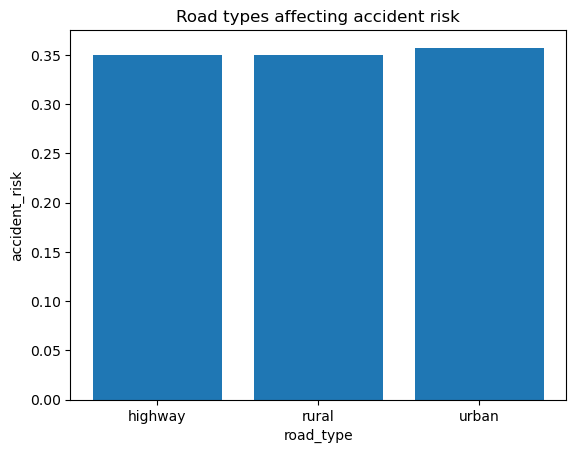

In [8]:
### Make bar chart for road_type_stats
plt.bar(road_type_stats['road_type'],road_type_stats['accident_risk'])
plt.title("Road types affecting accident risk")
plt.xlabel('road_type')
plt.ylabel('accident_risk')
plt.show()


In [9]:
weather_stats = df.groupby(['weather'])['accident_risk'].mean().reset_index()
print(weather_stats)

  weather  accident_risk
0   clear       0.310060
1   foggy       0.386305
2   rainy       0.361494


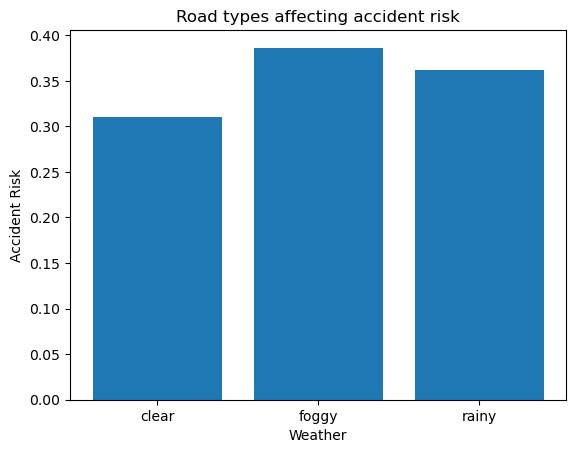

In [10]:
### Make bar chart here too
plt.bar(weather_stats['weather'],weather_stats['accident_risk'])
plt.title("Road types affecting accident risk")
plt.xlabel('Weather')
plt.ylabel('Accident Risk')
plt.show()

In [11]:
df.head(1)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,...,poor_visibility,night_bad_weather,rush_hour,high_traffic,road_complexity,safety_score,accidents_per_lane,high_accident_area,speed_category,curvature_level
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,...,0,0,0,0,0.02,NaN,0.47619,0,low,straight


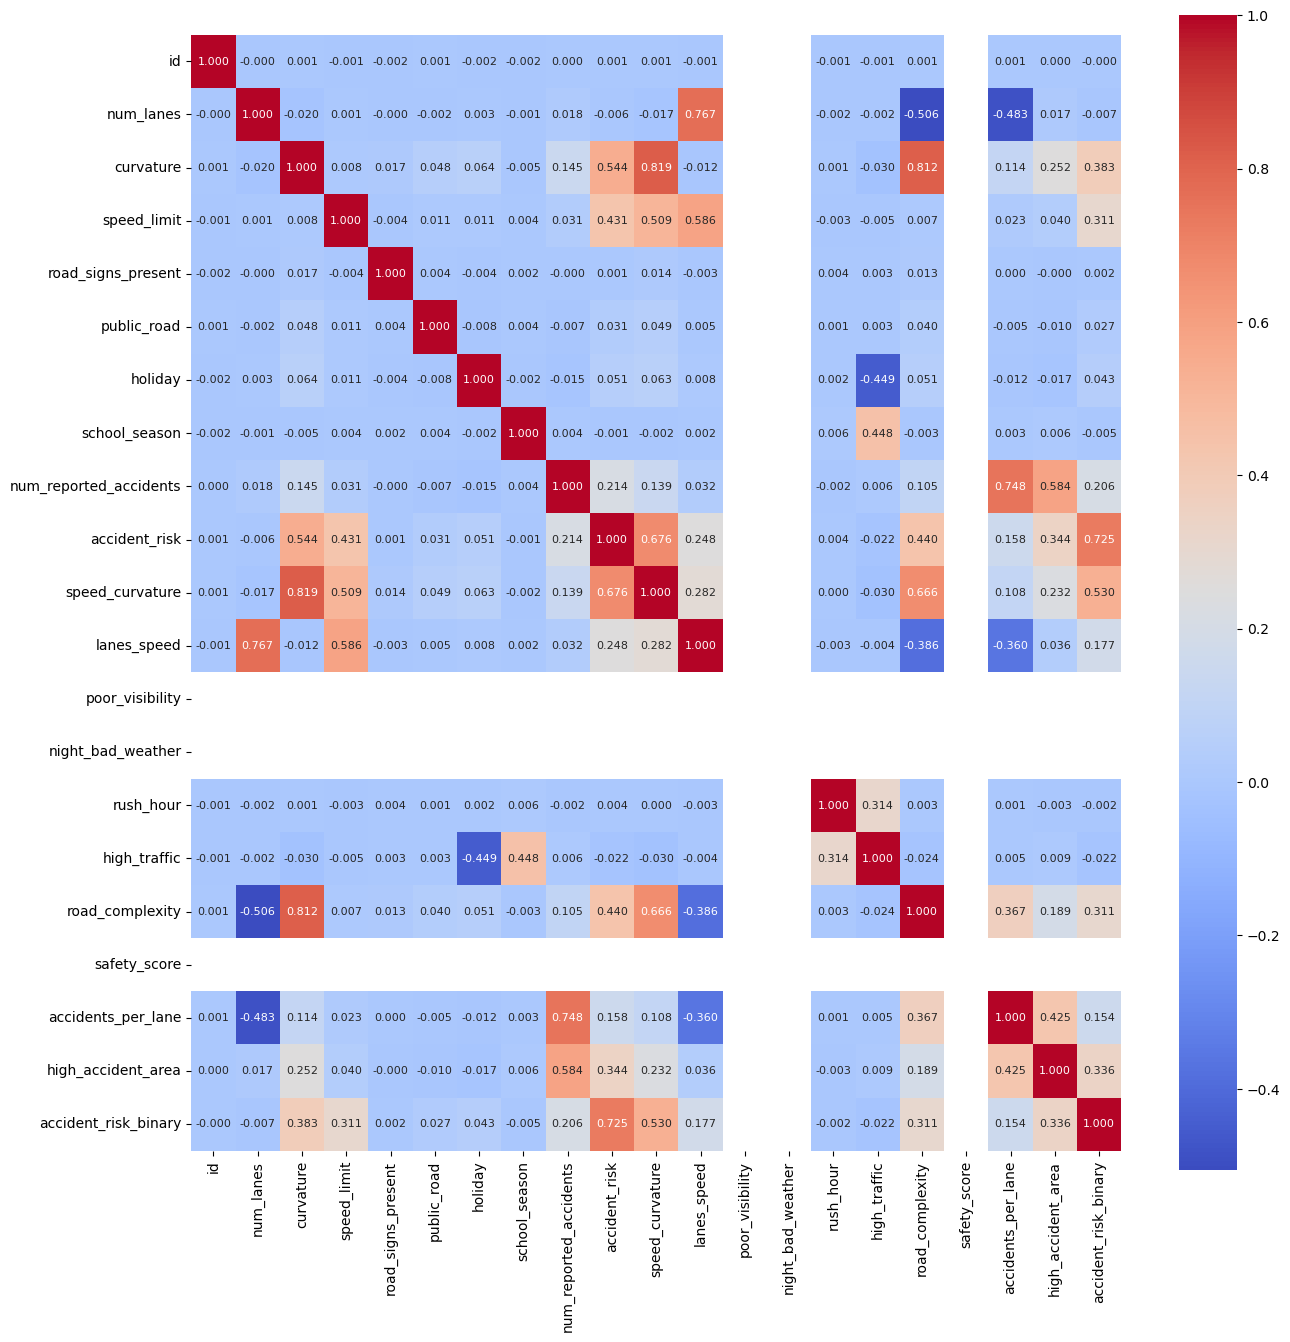

In [16]:

plt.figure(figsize=(15,15))
cor_matrix = df.corr(numeric_only = True)
heat_map = sns.heatmap(cor_matrix, cmap='coolwarm',fmt =".3f",annot_kws= {"size":8},annot=True)
heat_map.set_aspect(1.2)

### Inspecting the target variable 

We saw in df.describe that the mean accident risk across all variables is around 0.35 which is quite high. Now, let us look into more characteristics of this target variable and we will try to see the relation of the numerical variables on the target variable. We will do this by first changing the target variable into a binary variable. We will divide the accident risk into two: high risk instances (accident_risk > 0.5) and low risk instances. 

In [13]:
df['accident_risk_binary'] = (df['accident_risk'] > 0.5).astype(int)

In [14]:
df['accident_risk_binary'].value_counts()

accident_risk_binary
0    426581
1     91173
Name: count, dtype: int64

We see that there are almost 5 times as many instances of low accident risk than there are high accident risk instances.

In [15]:
curvature_stats = df.groupby(['accident_risk_binary'])['curvature'].mean().reset_index()
print(curvature_stats)

   accident_risk_binary  curvature
0                     0   0.440490
1                     1   0.714374


This provides us with some really useful insights about accident_risk. We see that on average, cases with higher accident risk tends to have a much higher curvature. This is expected as roads with a lot of curvature are generally harder to drive on.